## 1. Import and load data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Churn_Modelling.csv")
df.head()
df.info()
df.describe()
df['Exited'].value_counts(normalize=True)


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

## 2. Drop ID-like columns

In [2]:
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])


## 3. Check missing values

In [4]:
df.isna().sum()


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## Reframe to B2B “Accounts”
We now rename conceptually (you can keep original column names in code, but describe them as account features):

    Account = each row.

    Region = Geography.

    ProductsUsed = NumOfProducts.

    ACV (Annual Contract Value) proxy = use Balance or a simple transform.

Add engineered features:



In [5]:
# ACV proxy: use Balance directly as "contract value" stand-in
df["ACV"] = df["Balance"]

# Tenure in years
df["Tenure_Years"] = df["Tenure"] / 12

# Revenue bands
df["ACV_Band"] = pd.cut(
    df["ACV"],
    bins=[-0.01, 50000, 100000, df["ACV"].max()],
    labels=["Low", "Mid", "Enterprise"]
)


## EDA Plots

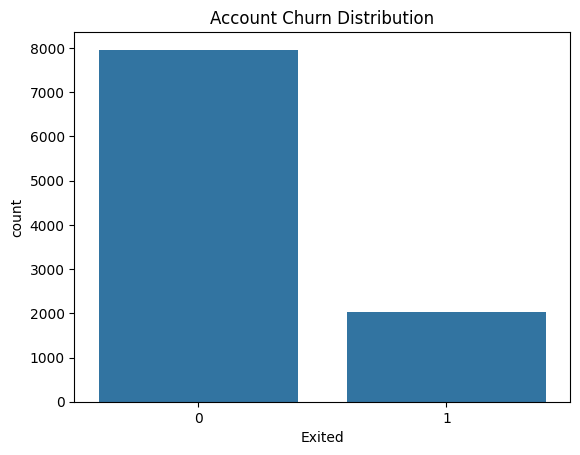

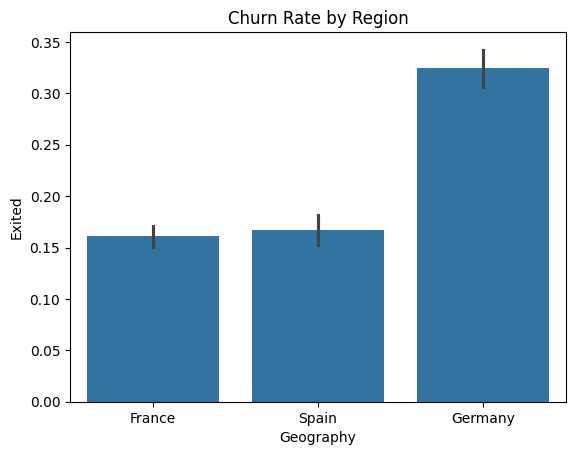

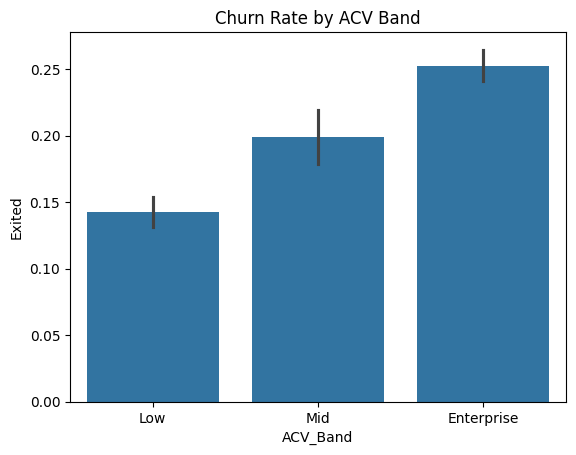

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Churn rate overall
sns.countplot(x="Exited", data=df)
plt.title("Account Churn Distribution")
plt.show()

# Churn by region
sns.barplot(x="Geography", y="Exited", data=df)
plt.title("Churn Rate by Region")
plt.show()

# Churn vs ACV band
sns.barplot(x="ACV_Band", y="Exited", data=df)
plt.title("Churn Rate by ACV Band")
plt.show()


## Save Cleaned Data

In [8]:
df.to_csv("../data/accounts_cleaned.csv", index=False)
